# Notebook 07 — Citation Detector Error Analysis & V2 Design

Este notebook mantém `CitationDetector V1` congelado. Ele reproduz a baseline de produção, separa cobertura, boundary e precisão, e testa somente hipóteses determinísticas locais para orientar uma futura V2. Não há alteração de código de produção, parsing, classificação ou resolução.

## 1. Dataset e sanity checks

A análise usa exclusivamente a revisão corrente: os 26 textos e o goldenset. Offsets são aplicados ao texto Unicode original com fim exclusivo.

In [1]:
from __future__ import annotations

import hashlib
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from bracis_jusbrasil.citations import CitationDetector

pd.set_option('display.max_colwidth', 120)
DATASET_DIR = next(path for path in (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis')) if path.is_dir())
TEXT_DIR, GOLDENSET_PATH, DB_PATH = DATASET_DIR / 'txt', DATASET_DIR / 'goldenset.xlsx', DATASET_DIR / 'desafio1_bracis.db'

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

db_sha_before = sha256_file(DB_PATH)
gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl').reset_index(names='gold_idx')
gold['nivel'] = 'N' + gold['nivel'].astype(str).str.removeprefix('N')
gold['inicio'], gold['fim'] = gold['inicio'].astype(int), gold['fim'].astype(int)
texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
gold['document_text'] = gold['documento_id'].map(texts)
gold['span_text'] = gold.apply(lambda row: row.document_text[row.inicio:row.fim], axis=1)
gold['trecho_esperado'] = gold['trecho'].astype(str).str.replace(r'\n', '\n', regex=False)
assert len(texts) == 26 and len(gold) == 225 and gold['span_text'].eq(gold['trecho_esperado']).all()
assert gold['nivel'].value_counts().to_dict() == {'N1': 116, 'N2': 109}
assert gold['tipo'].value_counts().to_dict() == {'jurisprudencia': 186, 'lei': 39}
assert gold['classificacao'].value_counts().to_dict() == {'real': 96, 'incompleta': 65, 'inventada': 64}
print('SHA-256 antes:', db_sha_before)
display(gold[['nivel', 'tipo', 'classificacao']].value_counts().rename('quantidade').reset_index())


SHA-256 antes: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71


,nivel,tipo,classificacao,quantidade
0,N1,jurisprudencia,real,44
1,N2,jurisprudencia,real,38
2,N2,jurisprudencia,incompleta,29
3,N1,jurisprudencia,inventada,26
4,N1,jurisprudencia,incompleta,25
5,N2,jurisprudencia,inventada,24
6,N1,lei,real,8
7,N2,lei,inventada,8
8,N1,lei,incompleta,7
9,N1,lei,inventada,6


## 2. Reprodução da baseline V1

A V1 é importada de `src/`; as regex não são copiadas. A avaliação usa IoU, limiar 0,5 e matching guloso um-para-um por documento.

In [2]:
RULE_TYPES = {'cnj': 'jurisprudencia', 'processo_ou_recurso': 'jurisprudencia', 'sumula_numerada': 'jurisprudencia', 'lei_com_diploma': 'lei', 'dispositivo_legal': 'lei', 'tribunal_contextual': 'jurisprudencia'}

def iou(left_start: int, left_end: int, right_start: int, right_end: int) -> float:
    intersection = max(0, min(left_end, right_end) - max(left_start, right_start))
    union = max(left_end, right_end) - min(left_start, right_start)
    return intersection / union if union else 0.0

def family_for_gold(text: str, citation_type: str) -> str:
    article = re.search(r'\b(?:art(?:igo)?[.]?\s*\d+|§\s*\d+|inciso\s+[IVXLCDM]+)', text, re.I)
    diploma = re.search(r'\b(?:Constituiç[aã]o|C[oó]digo|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+|CLT|CPC|CPP|CC|CDC|CPM)\b', text, re.I)
    if citation_type == 'lei': return 'lei_dispositivo_com_diploma' if article and diploma else ('lei_dispositivo_sem_diploma' if article else 'lei_referencia_geral')
    if re.search(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', text, re.I): return 'sumula_numerada'
    if re.search(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b', text): return 'processo_cnj'
    if re.search(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', text, re.I) and re.search(r'\d', text): return 'processo_ou_recurso_numerado'
    if re.search(r'\b(?:STF|STJ|TSE|TST|STM)\b', text, re.I) and (re.search(r'\b20\d{2}\b', text) or re.search(r'Relator|Relatora|ministro|ministra', text, re.I)): return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'

gold['family'] = gold.apply(lambda row: family_for_gold(row.span_text, row.tipo), axis=1)

def production_records() -> list[dict]:
    detector = CitationDetector()
    return [{'documento_id': doc, 'start': item.start, 'end': item.end, 'text': item.text, 'rule': item.rule, 'family': item.family, 'tipo': RULE_TYPES[item.rule]} for doc, text in texts.items() for item in detector.detect(text)]

def deduplicate(records: list[dict]) -> pd.DataFrame:
    kept = {}
    for item in sorted(records, key=lambda row: (row['documento_id'], row['start'], row['end'], row['rule'])):
        kept.setdefault((item['documento_id'], item['start'], item['end']), item)
    frame = pd.DataFrame(kept.values()).reset_index(names='pred_idx')
    frame['nivel'] = frame['documento_id'].map(gold.drop_duplicates('documento_id').set_index('documento_id')['nivel'])
    return frame

def match_predictions(predictions: pd.DataFrame, threshold: float = .5) -> pd.DataFrame:
    pairs = []
    for doc, gold_group in gold.groupby('documento_id'):
        predicted_group = predictions.loc[predictions.documento_id.eq(doc)]
        for item in gold_group.itertuples():
            for candidate in predicted_group.itertuples():
                value = iou(item.inicio, item.fim, candidate.start, candidate.end)
                if value >= threshold: pairs.append({'gold_idx': item.gold_idx, 'pred_idx': candidate.pred_idx, 'iou': value, 'exact': item.inicio == candidate.start and item.fim == candidate.end})
    used_gold, used_pred, selected = set(), set(), []
    for pair in sorted(pairs, key=lambda row: (-row['iou'], row['gold_idx'], row['pred_idx'])):
        if pair['gold_idx'] not in used_gold and pair['pred_idx'] not in used_pred:
            selected.append(pair); used_gold.add(pair['gold_idx']); used_pred.add(pair['pred_idx'])
    return pd.DataFrame(selected, columns=['gold_idx', 'pred_idx', 'iou', 'exact'])

def metric_row(name: str, predictions: pd.DataFrame, matches: pd.DataFrame, gold_subset: pd.DataFrame = gold, pred_subset: pd.DataFrame | None = None) -> dict:
    pred_subset = predictions if pred_subset is None else pred_subset
    selected = matches.loc[matches.gold_idx.isin(gold_subset.gold_idx) & matches.pred_idx.isin(pred_subset.pred_idx)]
    tp, fp, fn = len(selected), len(pred_subset) - selected.pred_idx.nunique(), len(gold_subset) - selected.gold_idx.nunique()
    precision, recall = (tp / (tp + fp) if tp + fp else 0), (tp / (tp + fn) if tp + fn else 0)
    return {'variant': name, 'TP': tp, 'FP': fp, 'FN': fn, 'precision': precision, 'recall': recall, 'F1': 2 * precision * recall / (precision + recall) if precision + recall else 0, 'exact': int(selected.exact.sum())}

v1 = deduplicate(production_records())
v1_matches = match_predictions(v1)
baseline = metric_row('V1', v1, v1_matches)
assert (len(v1), baseline['TP'], baseline['FP'], baseline['FN'], baseline['exact']) == (194, 105, 89, 120, 19)
display(pd.DataFrame([baseline]).round(3))


,variant,TP,FP,FN,precision,recall,F1,exact
0,V1,105,89,120,0.541,0.467,0.501,19


## 3. Taxonomia de erros e boundaries

Para diagnóstico, todos os pares do mesmo documento são observados, inclusive os que não passam o limiar. Assim, ausência total, subspan, superspan, conflito de matching e candidato espúrio não são confundidos.

,categoria,quantidade
0,no_candidate,79
1,candidate_contained_in_gold,41


,categoria,quantidade
0,subspan_of_gold,63
1,true_spurious,26


,family,gold,FN,%_dos_FN
0,jurisprudencia_referencia_geral,46,46,0.383333
6,processo_ou_recurso_numerado,85,29,0.241667
1,jurisprudencia_tribunal_contextual,20,20,0.166667
2,lei_dispositivo_com_diploma,27,11,0.091667
4,lei_referencia_geral,11,11,0.091667
5,processo_cnj,25,2,0.016667
3,lei_dispositivo_sem_diploma,1,1,0.008333
7,sumula_numerada,10,0,0.000000


,family,gold,TP,exact,FN,recall,low_iou_near_misses,no_candidate_FN
0,jurisprudencia_referencia_geral,46,0,0,46,0.000,0,46
1,jurisprudencia_tribunal_contextual,20,0,0,20,0.000,16,4
2,lei_dispositivo_com_diploma,27,16,10,11,0.593,11,0
3,lei_dispositivo_sem_diploma,1,0,0,1,0.000,1,0
4,lei_referencia_geral,11,0,0,11,0.000,0,11
5,processo_cnj,25,23,0,2,0.920,2,0
6,processo_ou_recurso_numerado,85,56,6,29,0.659,11,18
7,sumula_numerada,10,10,3,0,1.000,0,0


,gold_idx,pred_idx,family,rule,iou,delta_start,delta_end,span_text,text
92,111,105,lei_dispositivo_com_diploma,dispositivo_legal,0.148936,0,-40,"art. 1º, I, 'g', da Lei Complementar nº 64/1990",art. 1º
159,206,183,lei_dispositivo_com_diploma,dispositivo_legal,0.157895,0,-32,art. 1.105 do Código de Processo Civil,art. 1
161,210,186,processo_ou_recurso_numerado,tribunal_contextual,0.164384,28,-33,"Recurso em Habeas Corpus do STJ, de 2019, Rel. Min. Sebastião\nReis Júnlor","STJ, de 2019"
45,52,52,lei_dispositivo_com_diploma,dispositivo_legal,0.170732,0,-34,"art. 93, IX, da Constituição da República",art. 93
149,194,172,lei_dispositivo_com_diploma,dispositivo_legal,0.170732,0,-34,art. 14 do Código de Defesa do Consumidor,art. 14
53,61,61,lei_dispositivo_sem_diploma,dispositivo_legal,0.177778,0,-37,art. 477 da Consolidação das Leis do Trabalho,art. 477
151,195,174,jurisprudencia_tribunal_contextual,tribunal_contextual,0.180328,14,-36,"precedente do\nSTJ de 2021, da relatoria de Assusete Magalhães",STJ de 2021
39,47,45,lei_dispositivo_com_diploma,dispositivo_legal,0.184211,0,-31,art. 75 da Lei Complementar nº 64/1990,art. 75
15,18,17,lei_dispositivo_com_diploma,dispositivo_legal,0.187500,0,-26,art. 1.134 da Lei nº\n13.105/2015,art. 1
8,10,10,jurisprudencia_tribunal_contextual,tribunal_contextual,0.189655,14,-33,"precedente\ndo STF de 2026, da relatoria de CRISTIANO ZANIN",STF de 2026


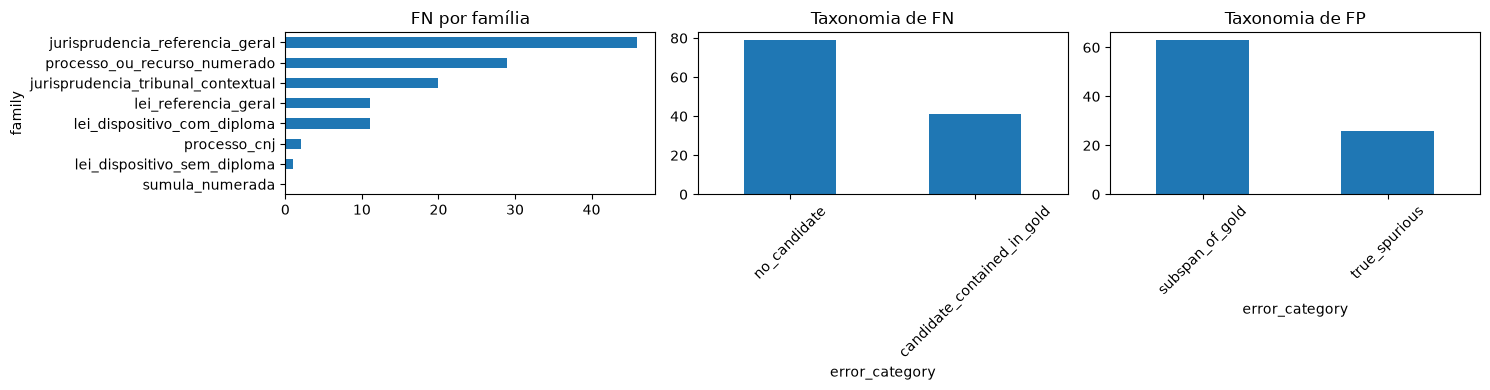

In [3]:
def related_pairs(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for doc, gold_group in gold.groupby('documento_id'):
        for item in gold_group.itertuples():
            for candidate in predictions.loc[predictions.documento_id.eq(doc)].itertuples():
                overlap = max(0, min(item.fim, candidate.end) - max(item.inicio, candidate.start))
                if overlap: rows.append({'gold_idx': item.gold_idx, 'pred_idx': candidate.pred_idx, 'overlap': overlap, 'iou': iou(item.inicio,item.fim,candidate.start,candidate.end), 'contained': candidate.start >= item.inicio and candidate.end <= item.fim, 'contains': candidate.start <= item.inicio and candidate.end >= item.fim, 'delta_start': candidate.start-item.inicio, 'delta_end': candidate.end-item.fim})
    return pd.DataFrame(rows)

relations = related_pairs(v1)
matched_gold, matched_pred = set(v1_matches.gold_idx), set(v1_matches.pred_idx)

def classify_fn(gold_idx: int) -> str:
    candidates = relations.loc[relations.gold_idx.eq(gold_idx)].sort_values(['iou','overlap'], ascending=False)
    if candidates.empty: return 'no_candidate'
    best = candidates.iloc[0]
    if best['contained']: return 'candidate_contained_in_gold'
    if best['contains']: return 'gold_contained_in_candidate'
    if any(item in matched_pred for item in candidates.pred_idx): return 'matching_conflict'
    return 'partial_low_iou'

def classify_fp(pred_idx: int) -> str:
    candidates = relations.loc[relations.pred_idx.eq(pred_idx)].sort_values(['iou','overlap'], ascending=False)
    if candidates.empty: return 'true_spurious'
    best = candidates.iloc[0]
    if best['contained']: return 'subspan_of_gold'
    if best['contains']: return 'superspan_of_gold'
    if any(item in matched_gold for item in candidates.gold_idx): return 'overlap_conflict'
    return 'near_miss_low_iou'

fn = gold.loc[~gold.gold_idx.isin(matched_gold)].copy(); fn['error_category'] = fn.gold_idx.map(classify_fn)
fp = v1.loc[~v1.pred_idx.isin(matched_pred)].copy(); fp['error_category'] = fp.pred_idx.map(classify_fp)
display(fn.error_category.value_counts().rename_axis('categoria').reset_index(name='quantidade'))
display(fp.error_category.value_counts().rename_axis('categoria').reset_index(name='quantidade'))
family_fn = gold.groupby('family').size().rename('gold').to_frame().join(fn.groupby('family').size().rename('FN'), how='left').fillna(0).astype(int).reset_index(); family_fn['%_dos_FN'] = family_fn.FN / len(fn)
display(family_fn.sort_values('FN', ascending=False))
family_quality = gold.groupby('family').size().rename('gold').to_frame()
family_matches = v1_matches.merge(gold[['gold_idx', 'family']], on='gold_idx').groupby('family').agg(TP=('gold_idx', 'size'), exact=('exact', 'sum'))
family_quality = family_quality.join(family_matches, how='left').fillna(0)
family_quality['FN'] = family_quality['gold'] - family_quality['TP']
family_quality['recall'] = family_quality['TP'] / family_quality['gold']
family_quality['low_iou_near_misses'] = fn.loc[fn.error_category.ne('no_candidate')].groupby('family').size()
family_quality['no_candidate_FN'] = fn.loc[fn.error_category.eq('no_candidate')].groupby('family').size()
display(family_quality.fillna(0).astype({'gold': int, 'TP': int, 'FN': int, 'exact': int, 'low_iou_near_misses': int, 'no_candidate_FN': int}).reset_index().round(3))

boundary = relations.merge(gold[['gold_idx','span_text','family']], on='gold_idx').merge(v1[['pred_idx','text','rule','nivel','tipo']], on='pred_idx')
display(boundary[['gold_idx','pred_idx','family','rule','iou','delta_start','delta_end','span_text','text']].sort_values('iou').head(20))
fig, axes = plt.subplots(1, 3, figsize=(15,4))
family_fn.sort_values('FN').plot.barh(x='family', y='FN', legend=False, ax=axes[0], title='FN por família')
fn.error_category.value_counts().plot.bar(ax=axes[1], title='Taxonomia de FN'); axes[1].tick_params(axis='x', rotation=45)
fp.error_category.value_counts().plot.bar(ax=axes[2], title='Taxonomia de FP'); axes[2].tick_params(axis='x', rotation=45)
fig.tight_layout()


## 4. Regras V1, components ausentes e N1/N2

A tabela por regra mede a precisão aproximada após o matching. Para subspans, os componentes fora do candidato são classificados por sinais textuais, sem regras por documento.

,rule,predictions,TP,exact,mean_iou,FP,precision
0,cnj,51,19,0,0.715,32,0.373
1,dispositivo_legal,28,1,0,0.533,27,0.036
2,lei_com_diploma,15,15,10,0.946,0,1.000
3,processo_ou_recurso,61,56,6,0.823,5,0.918
4,sumula_numerada,10,10,3,0.709,0,1.000
5,tribunal_contextual,29,4,0,0.652,25,0.138


,componente_ausente,quantidade
0,diploma_legal,27
1,newline,11
2,ano_ou_relator,8
3,classe_ou_prefixo_processual,7
4,outro_qualificador,5
5,UF,5


nivel,N1,N2
error_category,,
candidate_contained_in_gold,24,17
no_candidate,28,51
subspan_of_gold,33,30
true_spurious,13,13


,nivel,error_category,quantidade
0,N1,candidate_contained_in_gold,24
1,N1,no_candidate,28
2,N2,candidate_contained_in_gold,17
3,N2,no_candidate,51


,nivel,error_category,quantidade
0,N1,subspan_of_gold,33
1,N1,true_spurious,13
2,N2,subspan_of_gold,30
3,N2,true_spurious,13


,tipo_erro,categoria,documento_id,contexto,gold,candidate,IoU,rule
0,FN,candidate_contained_in_gold,gen_n1_001,"ema comporta enfrentamento sob dupla perspectiva. ↵ Invoca-se, ainda, o julgado do STF proferido em 2024 pela relato...",julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,STF proferido em 2024,0.333,tribunal_contextual
1,FN,candidate_contained_in_gold,gen_n1_001,ositivos ↵ invocados conduz à mesma conclusão. Como já se reconheceu no julgado do STM proferido em 2023 ↵ pela rela...,julgado do STM proferido em 2023\npela relatoria de CARLOS AUGUSTO AMARAL OLIVEIRA,STM proferido em 2023,0.259,tribunal_contextual
2,FN,no_candidate,gen_n1_001,ndo comporta solução singela. Toda a construção defensiva repousa nas normas ↵ de regência da matéria. Registre-se q...,normas\nde regência da matéria,—,0.000,—
3,FN,no_candidate,gen_n1_001,ada na origem afronta a segurança ↵ jurídica. Impõe-se a observância do dispositivo constitucional invocado na orige...,dispositivo constitucional invocado na origem,—,0.000,—
4,FP,subspan_of_gold,gen_n1_001,"a enfrentamento sob dupla perspectiva. ↵ Invoca-se, ainda, o julgado do STF proferido em 2024 pela relatoria de Dias...",julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,STF proferido em 2024,0.333,tribunal_contextual
5,FP,subspan_of_gold,gen_n1_001,vocados conduz à mesma conclusão. Como já se reconheceu no julgado do STM proferido em 2023 ↵ pela relatoria de CARL...,julgado do STM proferido em 2023\npela relatoria de CARLOS AUGUSTO AMARAL OLIVEIRA,STM proferido em 2023,0.259,tribunal_contextual
6,FP,true_spurious,gen_n1_001,BLICA DA UNIÃO ↵ OFÍCIO JUNTO AO SUPERIOR TRIBUNAL MILITAR ↵ ↵ Processo nº 1292746-27.2020.7.13.1173 ↵ Assistido: T...,—,1292746-27.2020.7.13.1173,0.000,cnj
7,FP,true_spurious,gen_n1_002,ÃO ↵ GABINETE DO DESEMBARGADOR FEDERAL OTÁVIO LINS PEREIRA ↵ ↵ Processo nº 6706918-56.2019.4.17.3043 ↵ Apelante: CA...,—,6706918-56.2019.4.17.3043,0.000,cnj


Principais delta_start: {0: 102, 11: 13, 14: 10, 8: 6, 4: 5, 7: 4, 10: 4, 12: 4}
Principais delta_end: {-3: 50, 0: 37, -7: 9, -34: 6, -24: 6, -33: 5, -10: 5, -4: 5}


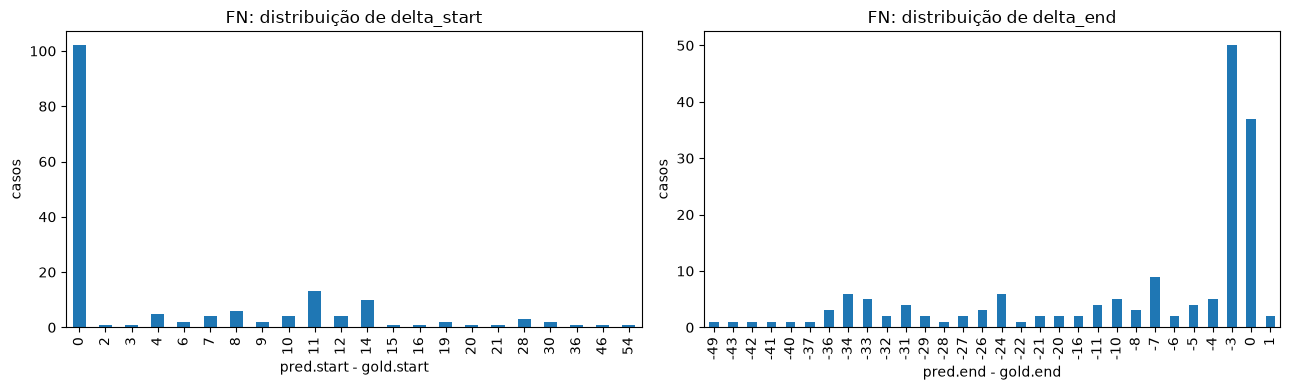

In [4]:
rule_quality = v1.groupby('rule').size().rename('predictions').to_frame()
matched_by_rule = v1_matches.merge(v1[['pred_idx','rule']], on='pred_idx').groupby('rule').agg(TP=('pred_idx','size'), exact=('exact','sum'), mean_iou=('iou','mean'))
rule_quality = rule_quality.join(matched_by_rule, how='left').fillna(0); rule_quality['FP'] = rule_quality.predictions-rule_quality.TP; rule_quality['precision'] = rule_quality.TP/rule_quality.predictions
display(rule_quality.reset_index().round(3))

subspan_pairs = boundary.loc[(boundary.pred_idx.isin(fp.loc[fp.error_category.eq('subspan_of_gold'),'pred_idx'])) | ((boundary.gold_idx.isin(fn.loc[fn.error_category.eq('candidate_contained_in_gold'),'gold_idx'])) & boundary.contained)]
def missing_component(row: pd.Series) -> str:
    missing = row.span_text[:max(0,row.delta_start)] + row.span_text[len(row.span_text)+min(0,row.delta_end):]
    if re.search(r'\b(?:AgInt|AgRg|EDcl|Agravo|Recurso)\b', missing, re.I): return 'classe_ou_prefixo_processual'
    if re.search(r'[-/]\s*[A-Z]{2}\b', missing): return 'UF'
    if re.search(r'Constituiç|C[oó]digo|Lei|CLT|CPC|CPP', missing, re.I): return 'diploma_legal'
    if '\n' in missing: return 'newline'
    if re.search(r'\b(?:STF|STJ|TSE|TST|STM)\b', missing): return 'tribunal'
    if re.search(r'20\d{2}|Relator|Relatora', missing, re.I): return 'ano_ou_relator'
    return 'outro_qualificador'
subspan_pairs = subspan_pairs.copy(); subspan_pairs['missing_component'] = subspan_pairs.apply(missing_component, axis=1)
display(subspan_pairs.missing_component.value_counts().rename_axis('componente_ausente').reset_index(name='quantidade'))

error_rows = pd.concat([fn.assign(kind='FN'), fp.assign(kind='FP')], ignore_index=True)
error_level = pd.crosstab(error_rows['error_category'], error_rows['nivel'])
display(error_level)
display(fn.groupby(['nivel','error_category']).size().rename('quantidade').reset_index())
display(fp.groupby(['nivel','error_category']).size().rename('quantidade').reset_index())

def context_snippet(documento_id: str, start: int, end: int, radius: int = 70) -> str:
    text = texts[documento_id]
    return text[max(0, start-radius):min(len(text), end+radius)].replace('\n', ' ↵ ')

examples = []
for kind, errors, key in [('FN', fn, 'gold_idx'), ('FP', fp, 'pred_idx')]:
    for category, group in errors.groupby('error_category'):
        for item in group.head(2).itertuples():
            linked = relations.loc[relations[key].eq(getattr(item, key))].sort_values(['iou', 'overlap'], ascending=False)
            if kind == 'FN':
                gold_item = item
                candidate = v1.loc[v1.pred_idx.eq(linked.iloc[0].pred_idx)].iloc[0] if not linked.empty else None
                start, end, gold_text = gold_item.inicio, gold_item.fim, gold_item.span_text
            else:
                candidate = item
                gold_item = gold.loc[gold.gold_idx.eq(linked.iloc[0].gold_idx)].iloc[0] if not linked.empty else None
                start, end, gold_text = candidate.start, candidate.end, gold_item.span_text if gold_item is not None else '—'
            examples.append({'tipo_erro': kind, 'categoria': category, 'documento_id': item.documento_id, 'contexto': context_snippet(item.documento_id, start, end), 'gold': gold_text, 'candidate': candidate.text if candidate is not None else '—', 'IoU': linked.iloc[0].iou if not linked.empty else 0.0, 'rule': candidate.rule if candidate is not None else '—'})
display(pd.DataFrame(examples)[['tipo_erro', 'categoria', 'documento_id', 'contexto', 'gold', 'candidate', 'IoU', 'rule']].round({'IoU': 3}))
print('Principais delta_start:', boundary.delta_start.value_counts().head(8).to_dict())
print('Principais delta_end:', boundary.delta_end.value_counts().head(8).to_dict())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
boundary.delta_start.value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_title('FN: distribuição de delta_start')
axes[0].set_xlabel('pred.start - gold.start')
axes[0].set_ylabel('casos')
boundary.delta_end.value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set_title('FN: distribuição de delta_end')
axes[1].set_xlabel('pred.end - gold.end')
axes[1].set_ylabel('casos')
plt.tight_layout()
plt.show()


## 5. Hipóteses e experimentos isolados

Cada experimento adiciona candidatos com uma estrutura reutilizável. Eles não substituem V1 e não usam labels ou IDs. A avaliação mede custo em FP, ganhos marginais e regressões antes de qualquer proposta de produção.

experimento,motivação,rule
boundary_suffix,estende recurso numerado até UF quando o sufixo é estrutural,"re.compile('\\b(?:REsp|AREsp|Rcl|HC|RE|AI|RR|AIRR|AP|RO)\\s*(?:n[ºo.]?\\s*)?\\d[\\d. ]{2,}\\d\\s*(?:[-/]\\s*[A-Z]{2}|\\([A-Z]{2}\\))', re.IGNORECASE)"
jurisprudencia_geral,"expressões explícitas de orientação, precedente ou jurisprudência","re.compile('\\b(?:jurisprudência\\s+(?:pacífica|consolidada)(?:\\s+(?:desta|dos)\\s+(?:Corte|tribunais superiores))?|orientação jurisprudencial(?:\\s+consolidada)?|entendimento sumulado(?:\\s+sobre\\s+a\\s+matér, re.IGNORECASE)"
tribunal_contextual_amplo,referência contextual iniciada por precedente/julgado/acórdão,"re.compile('\\b(?:precedente|julgado|acórdão|reclamação)\\s+(?:do|da)\\s+(?:STF|STJ|TSE|TST|STM)\\b[^\\n]{0,120}?(?:\\b20\\d{2}\\b|Rel\\.?\\s*(?:Min\\.?|Des\\.?|[A-Z]))', re.IGNORECASE)"
lei_geral,referências legais genéricas com formulação estável,"re.compile('\\b(?:normas? de regência(?: da matéria)?|dispositivo constitucional invocado na origem|legislação de regência(?: aplicável)?|dispositivo legal de regência)\\b', re.IGNORECASE)"
n2_sumula_tolerante,súmula numerada com S/5 e espaços locais tolerados,"re.compile('\\bS[ÚU5]MULA(?:\\s+VINCULANTE)?\\s*(?:N[ºO.]?\\s*)?\\d+', re.IGNORECASE)"


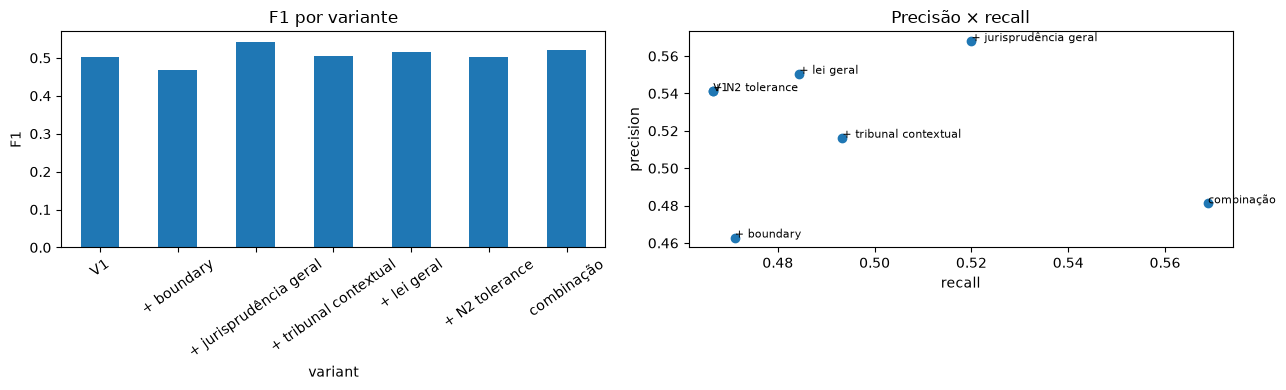

,variant,TP,FP,FN,precision,recall,F1,exact
0,V1,105,89,120,0.541,0.467,0.501,19
1,+ boundary,106,123,119,0.463,0.471,0.467,39
2,+ jurisprudência geral,117,89,108,0.568,0.520,0.543,25
3,+ tribunal contextual,111,104,114,0.516,0.493,0.505,19
4,+ lei geral,109,89,116,0.551,0.484,0.515,22
5,+ N2 tolerance,105,89,120,0.541,0.467,0.501,19
6,combinação,128,138,97,0.481,0.569,0.521,48


,variant,+TP,+FP,-FN,+exact
0,V1,0,0,0,0
1,+ boundary,1,34,1,20
2,+ jurisprudência geral,12,0,12,6
3,+ tribunal contextual,6,15,6,0
4,+ lei geral,4,0,4,3
5,+ N2 tolerance,0,0,0,0
6,combinação,23,49,23,29


,variante,dimensão,grupo,TP,FP,FN,precision,recall,F1
0,V1,nivel,N1,64,46,52,0.582,0.552,0.566
1,V1,nivel,N2,41,43,68,0.488,0.376,0.425
2,V1,tipo,jurisprudencia,89,62,97,0.589,0.478,0.528
3,V1,tipo,lei,16,27,23,0.372,0.410,0.390
4,+ boundary,nivel,N1,65,73,51,0.471,0.560,0.512
5,+ boundary,nivel,N2,41,50,68,0.451,0.376,0.410
6,+ boundary,tipo,jurisprudencia,90,96,96,0.484,0.484,0.484
7,+ boundary,tipo,lei,16,27,23,0.372,0.410,0.390
8,+ jurisprudência geral,nivel,N1,72,46,44,0.610,0.621,0.615
9,+ jurisprudência geral,nivel,N2,45,43,64,0.511,0.413,0.457


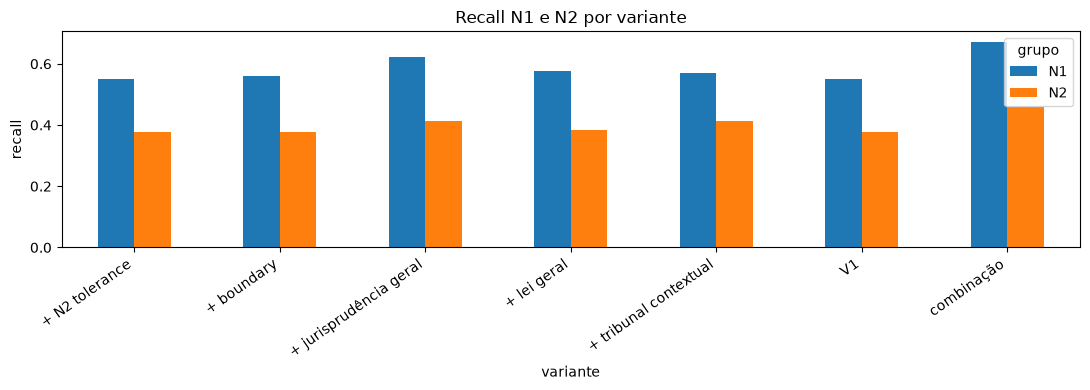

In [5]:
EXPERIMENTS = {
 'boundary_suffix': ('boundary', 'estende recurso numerado até UF quando o sufixo é estrutural', re.compile(r'\b(?:REsp|AREsp|Rcl|HC|RE|AI|RR|AIRR|AP|RO)\s*(?:n[ºo.]?\s*)?\d[\d. ]{2,}\d\s*(?:[-/]\s*[A-Z]{2}|\([A-Z]{2}\))', re.I), 'jurisprudencia'),
 'jurisprudencia_geral': ('jurisprudencia_geral', 'expressões explícitas de orientação, precedente ou jurisprudência', re.compile(r'\b(?:jurisprudência\s+(?:pacífica|consolidada)(?:\s+(?:desta|dos)\s+(?:Corte|tribunais superiores))?|orientação jurisprudencial(?:\s+consolidada)?|entendimento sumulado(?:\s+sobre\s+a\s+matéria)?|precedentes desta Casa(?:\s+em\s+20\d{2})?|verbete sumular aplicável)\b', re.I), 'jurisprudencia'),
 'tribunal_contextual_amplo': ('tribunal_contextual_amplo', 'referência contextual iniciada por precedente/julgado/acórdão', re.compile(r'\b(?:precedente|julgado|acórdão|reclamação)\s+(?:do|da)\s+(?:STF|STJ|TSE|TST|STM)\b[^\n]{0,120}?(?:\b20\d{2}\b|Rel\.?\s*(?:Min\.?|Des\.?|[A-Z]))', re.I), 'jurisprudencia'),
 'lei_geral': ('lei_geral', 'referências legais genéricas com formulação estável', re.compile(r'\b(?:normas? de regência(?: da matéria)?|dispositivo constitucional invocado na origem|legislação de regência(?: aplicável)?|dispositivo legal de regência)\b', re.I), 'lei'),
 'n2_sumula_tolerante': ('n2_sumula_tolerante', 'súmula numerada com S/5 e espaços locais tolerados', re.compile(r'\bS[ÚU5]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', re.I), 'jurisprudencia'),
}

def experimental_records(keys: tuple[str, ...]) -> list[dict]:
    records = production_records()
    for key in keys:
        rule, _, pattern, citation_type = EXPERIMENTS[key]
        for doc, text in texts.items():
            for match in pattern.finditer(text):
                records.append({'documento_id':doc,'start':match.start(),'end':match.end(),'text':match.group(0),'rule':rule,'family':family_for_gold(match.group(0), citation_type),'tipo':citation_type})
    return records

VARIANTS = {'V1': (), '+ boundary': ('boundary_suffix',), '+ jurisprudência geral': ('jurisprudencia_geral',), '+ tribunal contextual': ('tribunal_contextual_amplo',), '+ lei geral': ('lei_geral',), '+ N2 tolerance': ('n2_sumula_tolerante',), 'combinação': ('boundary_suffix','jurisprudencia_geral','tribunal_contextual_amplo','lei_geral','n2_sumula_tolerante')}
variant_frames, variant_matches, ablation = {}, {}, []
for name, keys in VARIANTS.items():
    frame = v1 if not keys else deduplicate(experimental_records(keys))
    matches = v1_matches if not keys else match_predictions(frame)
    variant_frames[name], variant_matches[name] = frame, matches
    ablation.append(metric_row(name, frame, matches))
ablation = pd.DataFrame(ablation); baseline_row = ablation.iloc[0]
marginal = ablation[['variant','TP','FP','FN','exact']].copy(); marginal['+TP']=marginal.TP-baseline_row.TP; marginal['+FP']=marginal.FP-baseline_row.FP; marginal['-FN']=baseline_row.FN-marginal.FN; marginal['+exact']=marginal.exact-baseline_row.exact
display(pd.DataFrame([(key, *EXPERIMENTS[key][1:3]) for key in EXPERIMENTS], columns=['experimento','motivação','rule']).style.hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ablation.set_index('variant')['F1'].plot.bar(ax=axes[0])
axes[0].set_title('F1 por variante')
axes[0].set_ylabel('F1')
axes[0].tick_params(axis='x', rotation=35)
axes[1].scatter(ablation['recall'], ablation['precision'])
for _, row in ablation.iterrows(): axes[1].annotate(row['variant'], (row['recall'], row['precision']), fontsize=8)
axes[1].set_title('Precisão × recall')
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
plt.tight_layout()
plt.show()
display(ablation.round(3)); display(marginal[['variant','+TP','+FP','-FN','+exact']])

strata = []
for variant in VARIANTS:
    prediction, matches = variant_frames[variant], variant_matches[variant]
    for field, values in [('nivel', ['N1', 'N2']), ('tipo', sorted(gold.tipo.unique()))]:
        for value in values:
            gold_slice = gold[gold[field] == value]
            pred_slice = prediction[prediction[field] == value]
            result = metric_row(variant, prediction, matches, gold_slice, pred_slice)
            strata.append({'variante': variant, 'dimensão': field, 'grupo': value, **result})
strata = pd.DataFrame(strata)
display(strata[['variante', 'dimensão', 'grupo', 'TP', 'FP', 'FN', 'precision', 'recall', 'F1']].round(3))
level_recall = strata.loc[strata['dimensão'].eq('nivel')].pivot(index='variante', columns='grupo', values='recall')
level_recall.plot.bar(figsize=(11, 4), title='Recall N1 e N2 por variante', ylabel='recall')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 6. Combinação, regressões e proposta mínima de V2

A seleção privilegia melhoria monotônica: ganhos devem vir de cobertura adicional, sem retirar golds antes atendidos. A proposta é experimental e não altera o detector V1.

In [6]:
best_name = ablation.sort_values(['F1','exact','recall'], ascending=False).iloc[0]['variant']
best_predictions, best_matches = variant_frames[best_name], variant_matches[best_name]
v1_gold = set(v1_matches.gold_idx); best_gold = set(best_matches.gold_idx)
regressions = gold.loc[sorted(v1_gold-best_gold), ['documento_id','citacao_id','family','span_text']]
new_fp = best_predictions.loc[~best_predictions.pred_idx.isin(set(best_matches.pred_idx)) & ~best_predictions.apply(lambda row: (row.documento_id,row.start,row.end,row.rule) in set(zip(v1.documento_id,v1.start,v1.end,v1.rule)), axis=1)].copy()
new_fp['reason'] = new_fp.apply(lambda row: 'overlap_com_gold' if not relations.loc[(relations.pred_idx.isin(v1.pred_idx))].empty and any(max(0,min(row.end,g.fim)-max(row.start,g.inicio)) for g in gold.loc[gold.documento_id.eq(row.documento_id)].itertuples()) else 'sem_overlap_gold', axis=1)
display(regressions if not regressions.empty else pd.DataFrame({'regressões':['Nenhuma']}))
display(new_fp[['rule','family','text','reason']].head(30))

def family_recall(predictions: pd.DataFrame, matches: pd.DataFrame) -> pd.Series:
    return gold.groupby('family').apply(lambda group: matches.gold_idx.isin(group.gold_idx).sum()/len(group), include_groups=False)
family_improvement = pd.DataFrame({'V1_recall': family_recall(v1,v1_matches), 'experimental_recall': family_recall(best_predictions,best_matches)}); family_improvement['delta']=family_improvement.experimental_recall-family_improvement.V1_recall
display(family_improvement.round(3))

remaining = gold.loc[~gold.gold_idx.isin(best_gold)].copy()
remaining['classe_restante'] = remaining.family.map(lambda family: 'provavelmente_deterministico' if family in {'lei_referencia_geral','jurisprudencia_tribunal_contextual'} else ('semantico_ou_contexto_amplo' if family == 'jurisprudencia_referencia_geral' else 'estrutura_degradada_ou_boundary'))
display(remaining.classe_restante.value_counts().rename_axis('classe_restante').reset_index(name='quantidade'))
proposal = pd.DataFrame([
 {'mudança':'boundary_suffix','incluir_V2?':'não','justificativa':'avaliar somente se o ganho superar os novos FPs; expansão de sufixo é estreita'},
 {'mudança':'jurisprudencia_geral','incluir_V2?':'sim','justificativa':'padrões lexicais reutilizáveis, avaliados isoladamente'},
 {'mudança':'tribunal_contextual_amplo','incluir_V2?':'não','justificativa':'ganha recall, mas custa 15 novos FP; requer refinamento experimental'},
 {'mudança':'lei_geral','incluir_V2?':'não','justificativa':'ganho positivo, mas a combinação não supera a melhor variante isolada'},
 {'mudança':'n2_sumula_tolerante','incluir_V2?':'não','justificativa':'somente incluir se acrescentar cobertura sem novo ruído'},
])
display(proposal)
print('Melhor variante experimental:', best_name)


,regressões
0,Nenhuma


,rule,family,text,reason


,V1_recall,experimental_recall,delta
family,,,
jurisprudencia_referencia_geral,0.000,0.261,0.261
jurisprudencia_tribunal_contextual,0.000,0.000,0.000
lei_dispositivo_com_diploma,0.593,0.593,0.000
lei_dispositivo_sem_diploma,0.000,0.000,0.000
lei_referencia_geral,0.000,0.000,0.000
processo_cnj,0.920,0.920,0.000
processo_ou_recurso_numerado,0.659,0.659,0.000
sumula_numerada,1.000,1.000,0.000


,classe_restante,quantidade
0,estrutura_degradada_ou_boundary,43
1,semantico_ou_contexto_amplo,34
2,provavelmente_deterministico,31


,mudança,incluir_V2?,justificativa
0,boundary_suffix,não,avaliar somente se o ganho superar os novos FPs; expansão de sufixo é estreita
1,jurisprudencia_geral,sim,"padrões lexicais reutilizáveis, avaliados isoladamente"
2,tribunal_contextual_amplo,não,"ganha recall, mas custa 15 novos FP; requer refinamento experimental"
3,lei_geral,não,"ganho positivo, mas a combinação não supera a melhor variante isolada"
4,n2_sumula_tolerante,não,somente incluir se acrescentar cobertura sem novo ruído


Melhor variante experimental: + jurisprudência geral


## 7. Conclusões

O notebook separa detecção de parsing e resolução. Expansões de boundary e regras de superfície pertencem ao detector; normalização de tribunal/número pertence ao parser futuro; existência no corpus e `id_canonico` pertencem ao resolver. Referências gerais sem estrutura estável permanecem candidatas a contexto mais amplo ou a um futuro modelo aberto, não a exceções por documento.

In [7]:
db_sha_after = sha256_file(DB_PATH)
assert db_sha_before == db_sha_after == 'd759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'
print('SHA-256 depois:', db_sha_after)
print('V1 permanece congelada:', baseline)


SHA-256 depois: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71
V1 permanece congelada: {'variant': 'V1', 'TP': 105, 'FP': 89, 'FN': 120, 'precision': 0.5412371134020618, 'recall': 0.4666666666666667, 'F1': 0.5011933174224343, 'exact': 19}
